# Self-Supervised Learning

## Start with the problem: images are plentiful, labels are limited

Suppose we have many digit images but can obtain class labels for only a small training subset. Ordinary supervised classification uses a human-provided digit label to tell the CNN what to learn. Can the other images teach it anything useful before those labels are available?

**Self-supervised learning** constructs a training target from the data itself. Here we hide selected pixels, give the network the remaining image and a mask, and ask it to reconstruct the hidden original values. Those original values provide a measurable error without supplying a digit class. Backpropagation and an optimizer still do the learning; self-supervision changes where the targets come from.

We pretrain a small CNN encoder on masked images from the bundled handwritten-digits dataset, then reuse it for classification with only 20 labeled training images per digit. We compare frozen learned features, frozen random features, fine-tuning, and training from scratch. The experiment runs on CPU without downloads and does not depend on earlier notebooks.

The [companion notes](19_Self_Supervised_Learning_Notes.ipynb) illustrate the workflow. Reconstruction targets come from image values; class labels are kept out of pretraining losses and pretraining checkpoint selection.

In [1]:
import copy
import tempfile
from pathlib import Path
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

torch.manual_seed(17)
torch.set_num_threads(1)
np.random.seed(17)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('CPU | masked-pixel pretraining | class labels used only downstream')

CPU | masked-pixel pretraining | class labels used only downstream


## Create a question whose answer is already in the data

For a two-pixel teaching image, let the original values be $x=[1,0.8]$. Hide the second pixel: the model receives visible values $[1,0]$ and mask $[0,1]$, where one means hidden. Its reconstruction target for the hidden position is the original $0.8$.

The zero at a hidden position is a placeholder, not the target. The mask distinguishes it from a genuinely black visible pixel. In the real project, visible values and mask form two input channels. Original hidden values are supplied only to the loss, not to the encoder input.

For a prediction $\hat x$, use the mean squared error over hidden positions only:

$$L=\frac{\sum_j M_j(\hat x_j-x_j)^2}{\sum_j M_j}.$$

If the hidden prediction is $0.2$, its error is $0.2-0.8=-0.6$ and loss is $(-0.6)^2=0.36$. The visible position contributes zero regardless of its predicted value. With one hidden and one perfectly copied visible pixel, averaging over both would give $0.18$ instead, diluting the hidden-pixel task. We always hide exactly 16 of the 64 image pixels, so each image contributes equally to the batch's masked loss.

A network could trivially copy an unhidden target. Removing selected values forces it to exploit context to predict those values, although easy background pixels and familiar local statistics can still make the task easier than recognition.

## Follow one self-supervised update completely

Use a miniature encoder $h=\operatorname{ReLU}(a x_1)$ and decoder $\hat x_2=wh$, with $a=0.5$, $w=0.4$, visible $x_1=1$, and hidden target $x_2=0.8$. There are two trainable parameters and no biases.

**Forward:** $h=\max(0,0.5\times1)=0.5$; prediction is $0.4\times0.5=0.2$; loss is $(0.2-0.8)^2=0.36$.

**Backward:** the prediction derivative is $2(0.2-0.8)=-1.2$. The decoder-weight derivative is $-1.2h=-1.2(0.5)=-0.6$. The hidden-feature derivative is $-1.2w=-1.2(0.4)=-0.48$. ReLU's slope is one here, so the encoder-weight derivative is $-0.48(1)(x_1)=-0.48$.

**Update:** with SGD rate $0.1$, $w'=0.4-0.1(-0.6)=0.46$ and $a'=0.5-0.1(-0.48)=0.548$. Using both updated weights, the next prediction is $0.46(0.548)=0.25208$, and loss is $(0.25208-0.8)^2\approx0.300216$, lower than $0.36$.

No one supplied a class such as “eight.” The original hidden pixel supplied the numerical target, and its reconstruction error changed the encoder as well as the decoder. Across many images and masks, this can teach structure that may help another task. One reconstruction improvement alone does not demonstrate that the features distinguish digit classes.

In [2]:
a = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
w = torch.tensor(0.4, dtype=torch.float64, requires_grad=True)
visible_pixel = torch.tensor(1., dtype=torch.float64)
hidden_target = torch.tensor(0.8, dtype=torch.float64)
predicted_pixel = w * (a * visible_pixel).relu()
loss = (predicted_pixel - hidden_target).square()
loss.backward()
torch.testing.assert_close(a.grad, torch.tensor(-0.48, dtype=torch.float64))
torch.testing.assert_close(w.grad, torch.tensor(-0.6, dtype=torch.float64))
with torch.no_grad():
    a -= 0.1 * a.grad
    w -= 0.1 * w.grad
    new_prediction = w * (a * visible_pixel).relu()
    new_loss = (new_prediction - hidden_target).square()
torch.testing.assert_close(new_prediction, torch.tensor(0.25208, dtype=torch.float64))
assert new_loss < loss
print(f'Hidden-pixel prediction: 0.200000 -> {new_prediction.item():.6f}')
print(f'Reconstruction loss: {loss.item():.6f} -> {new_loss.item():.6f}')

Hidden-pixel prediction: 0.200000 -> 0.252080
Reconstruction loss: 0.360000 -> 0.300216


## Recognize a second approach: make related views agree

Masked prediction is one form of self-supervision. In a simple **contrastive** formulation, two transformations of the same image form a positive pair. Representations from other images provide negative candidates. The objective rewards a larger similarity to the positive than to the negatives.

For one positive similarity $0.9$, one negative similarity $0.2$, and temperature $\tau=0.5$, the scores are $[0.9/0.5,0.2/0.5]=[1.8,0.4]$. The positive probability is

$$p_+=\frac{e^{1.8}}{e^{1.8}+e^{0.4}}\approx0.802184,$$

and the loss is $-\ln p_+\approx0.220417$. The similarity derivatives are $(p_+-1)/\tau\approx-0.395632$ for the positive and $(1-p_+)/\tau\approx0.395632$ for the negative. The objective encourages increasing the former and decreasing the latter.

If all representations collapse to one identical vector, both similarities are equal, giving probability $0.5$ and loss $\ln2\approx0.693147$ for this two-candidate case. This simple contrastive objective prefers separation to that collapsed solution, though successful optimization is a separate question. Merely making positive views identical without any additional constraint can admit trivial constant representations.

Transformations must preserve the information the downstream task needs. Arbitrary digit rotations or flips can change class meaning. Other images can also share the same digit, so treating all of them as negatives can introduce false negatives. The code checks the arithmetic here, but the trained project below uses masked reconstruction, not contrastive training.

In [3]:
similarities = torch.tensor([0.9, 0.2], dtype=torch.float64, requires_grad=True)
temperature = 0.5
contrastive_loss = F.cross_entropy((similarities / temperature)[None], torch.tensor([0]))
contrastive_loss.backward()
probabilities = (similarities.detach() / temperature).softmax(0)
expected_gradient = (probabilities - torch.tensor([1., 0.], dtype=torch.float64)) / temperature
torch.testing.assert_close(similarities.grad, expected_gradient)
collapsed_loss = F.cross_entropy(torch.ones(1, 2, dtype=torch.float64), torch.tensor([0]))
torch.testing.assert_close(collapsed_loss, torch.tensor(np.log(2), dtype=torch.float64))
print('Positive probability:', probabilities[0].item(), '| contrastive loss:', contrastive_loss.item())
print('Similarity gradients:', similarities.grad.tolist(), '| equal-score loss:', collapsed_loss.item())

Positive probability: 0.8021838885585817 | contrastive loss: 0.220417409918451
Similarity gradients: [-0.3956322228828366, 0.3956322228828365] | equal-score loss: 0.6931471805599453


## Separate pretraining data from downstream evaluation

Start with the bundled 1,797 digit images. Reserve 20% for final classification testing and 20% for classification validation. Split the remaining training pool randomly into pretraining training and pretraining validation groups. Only those two groups participate in reconstruction learning or reconstruction checkpoint selection.

From the pretraining training group, select 20 images per digit for the labeled classification subset, totaling 200. These images may be seen without labels during pretraining and later with labels during adaptation; that is the intended reuse. The remaining pretraining training images are additional inputs available without class labels. The entire scratch comparison uses only the 200 labeled images.

Class labels are used to stratify the downstream split and choose the balanced labeled subset. They are never inputs or targets in the reconstruction loop. This is a simulated labeling budget on an already labeled benchmark, not a dataset whose labels literally do not exist. Downstream validation also consumes labels and must be counted when discussing cost.

Classification validation and test images are excluded even from unlabeled pretraining. Index-disjoint splits do not establish writer independence because writer groups are not provided by this loader. Pixel scaling is a fixed division by 16, not a statistic estimated from held-out images.

In [4]:
digits = load_digits()
raw_images = digits.images.astype(np.float32)
labels = digits.target.astype(np.int64)
all_ids = np.arange(len(labels))
pool_ids, test_ids = train_test_split(all_ids, test_size=0.2, stratify=labels, random_state=17)
pool_ids, val_ids = train_test_split(pool_ids, test_size=0.25, stratify=labels[pool_ids], random_state=17)
ssl_train_ids, ssl_val_ids = train_test_split(pool_ids, test_size=0.2, random_state=170)
rng = np.random.default_rng(171)
labeled_ids = np.concatenate([rng.choice(ssl_train_ids[labels[ssl_train_ids] == digit], 20, replace=False)
                              for digit in range(10)])
rng.shuffle(labeled_ids)
roles = [ssl_train_ids, ssl_val_ids, val_ids, test_ids]
for i, ids in enumerate(roles):
    for other in roles[i+1:]:assert not set(ids) & set(other)
assert set(np.concatenate(roles)) == set(all_ids)
assert set(labeled_ids) <= set(ssl_train_ids)
assert np.array_equal(np.bincount(labels[labeled_ids], minlength=10), np.full(10, 20))

def pixels(ids):
    return torch.from_numpy(raw_images[ids] / 16.0)[:, None]

ssl_train_x, ssl_val_x = pixels(ssl_train_ids), pixels(ssl_val_ids)
labeled_x, labeled_y = pixels(labeled_ids), torch.from_numpy(labels[labeled_ids])
val_x, val_y = pixels(val_ids), torch.from_numpy(labels[val_ids])
print('Pretraining training/validation:', len(ssl_train_ids), len(ssl_val_ids))
print('Labeled classification training/validation/test:', len(labeled_ids), len(val_ids), len(test_ids))
print('Additional pretraining training images without class-label use:', len(ssl_train_ids)-len(labeled_ids))

Pretraining training/validation: 861 216
Labeled classification training/validation/test: 200 360 360
Additional pretraining training images without class-label use: 661


## Construct masks without leaking the answer into the input

For each image, choose exactly 16 of its 64 positions uniformly using random scores. Set those intensities to zero and concatenate the binary mask as a second channel. The tensor shape becomes `(N, 2, 8, 8)`: one visible-intensity channel and one hidden-position channel.

Draw fresh masks during every pretraining pass so the model cannot memorize one fixed question per training image. Use one seeded, fixed mask per pretraining validation image so checkpoint comparisons measure the same questions. This is only one mask sample per validation image and should not be mistaken for an exhaustive reconstruction evaluation.

Keep the clean image separately for calculating the loss. The masked loss explicitly indexes the hidden positions through multiplication by the mask; it never feeds the clean image to the encoder. We also compute a baseline that predicts the mean pretraining-training image, one average value per pixel position. Beating that baseline asks whether context helps beyond typical pixel brightness.

Model input shape: (4, 2, 8, 8)
Pretraining validation mean-image baseline MSE: 0.07359049469232559


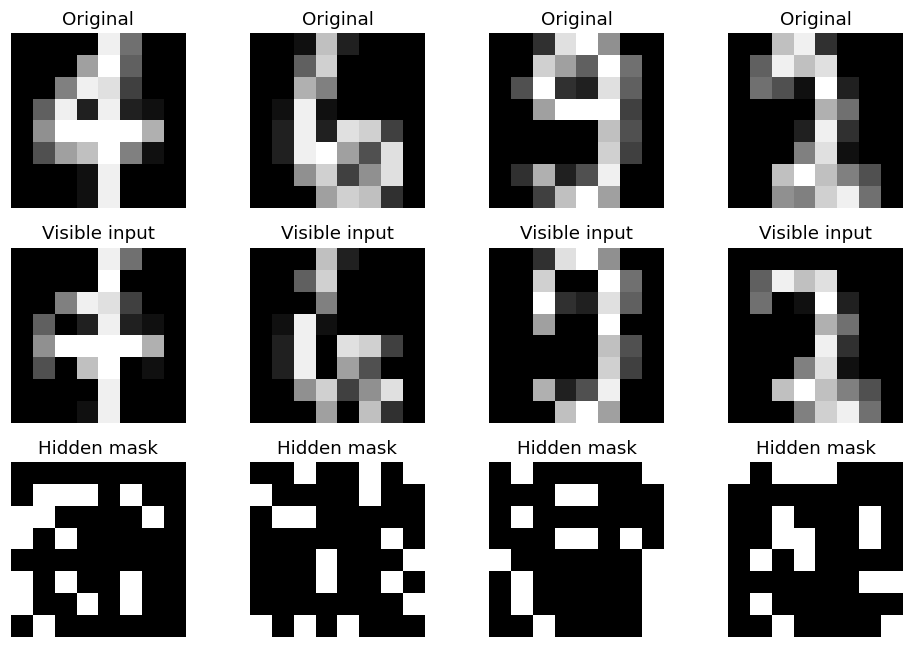

In [5]:
def masked_inputs(clean, generator):
    count = len(clean)
    positions = torch.rand(count, 64, generator=generator).argsort(dim=1)[:, :16]
    flat_mask = torch.zeros(count, 64, dtype=clean.dtype)
    flat_mask.scatter_(1, positions, 1.0)
    mask = flat_mask.reshape(count, 1, 8, 8)
    visible = clean * (1-mask)
    inputs = torch.cat([visible, mask], dim=1)
    assert torch.all(mask.sum((1, 2, 3)) == 16)
    assert torch.count_nonzero(visible * mask) == 0
    return inputs, mask

def masked_mse(prediction, clean, mask):
    assert prediction.shape == clean.shape == mask.shape
    return ((prediction-clean).square()*mask).sum() / mask.sum()

validation_inputs, validation_mask = masked_inputs(ssl_val_x, torch.Generator().manual_seed(172))
mean_image = ssl_train_x.mean(0, keepdim=True)
mean_baseline_loss = masked_mse(mean_image.expand_as(ssl_val_x), ssl_val_x, validation_mask).item()
example_inputs, example_mask = masked_inputs(ssl_train_x[:4], torch.Generator().manual_seed(173))
fig, axes = plt.subplots(3, 4, figsize=(9, 6))
for column in range(4):
    for row, (values, name) in enumerate([(ssl_train_x[:, 0], 'Original'),
                                         (example_inputs[:, 0], 'Visible input'),
                                         (example_mask[:, 0], 'Hidden mask')]):
        axes[row, column].imshow(values[column], cmap='gray', vmin=0, vmax=1)
        axes[row, column].set_title(name); axes[row, column].axis('off')
plt.tight_layout(); plt.show()
print('Model input shape:', tuple(example_inputs.shape))
print('Pretraining validation mean-image baseline MSE:', mean_baseline_loss)

## Train an encoder to carry information needed for reconstruction

The encoder uses Conv(2 → 8) → ReLU → MaxPool → Conv(8 → 16) → ReLU → MaxPool → Flatten. Both filters are 3 × 3 with padding one. Its 64 features come from sixteen 2 × 2 maps. The extra input channel is the mask, not another color.

A small decoder maps those 64 features to 64 pixel predictions, applies sigmoid to constrain outputs to $[0,1]$, and reshapes them to 8 × 8. Sigmoid output is a pixel-value prediction here, not a probability distribution over classes. We train using masked MSE, not classification cross-entropy.

The encoder has $8(2\times3\times3+1)+16(8\times3\times3+1)=152+1168=1320$ parameters. The decoder has $64(64+1)=4160$, giving 5,480 reconstruction parameters. The representation is not a lower-dimensional bottleneck than the original 64-pixel image; the missing inputs create the learning challenge.

Adam trains on fresh training masks for 30 epochs. The lowest fixed-mask pretraining validation loss selects a checkpoint, including the initial state as a candidate. We retain a copy of the original random encoder to provide a controlled random-feature baseline later. Neither a low reconstruction loss nor a pleasing reconstruction guarantees useful digit classes in the features.

Selected pretraining epoch: 30
Masked validation MSE: network 0.042529; mean-image baseline 0.073590


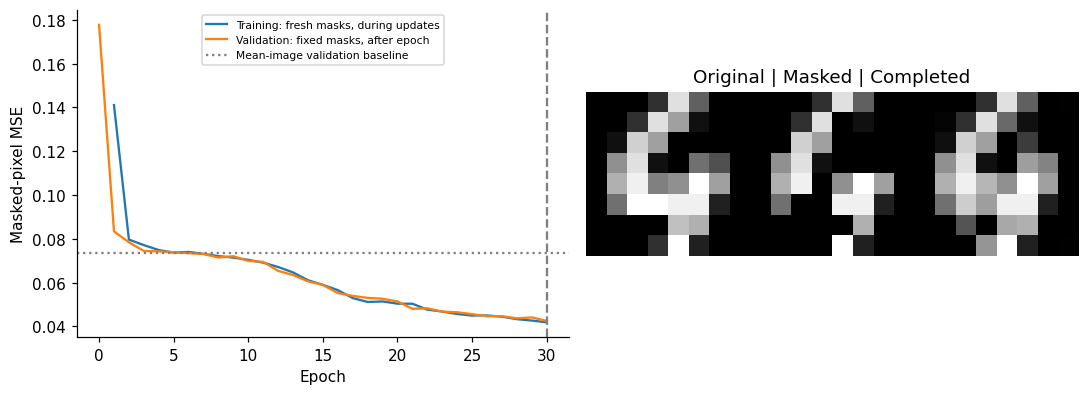

In [6]:
def make_encoder():
    return nn.Sequential(nn.Conv2d(2, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                         nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), nn.Flatten())

class MaskedPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = make_encoder()
        self.decoder = nn.Sequential(nn.Linear(64, 64), nn.Sigmoid(), nn.Unflatten(1, (1, 8, 8)))
    def forward(self, inputs):
        return self.decoder(self.encoder(inputs))

torch.manual_seed(174)
pretrained = MaskedPredictor()
random_encoder_state = copy.deepcopy(pretrained.encoder.state_dict())
assert sum(p.numel() for p in pretrained.encoder.parameters()) == 1320
assert sum(p.numel() for p in pretrained.parameters()) == 5480
pretrain_optimizer = torch.optim.Adam(pretrained.parameters(), lr=0.003)
mask_generator = torch.Generator().manual_seed(175)
shuffle_generator = torch.Generator().manual_seed(176)
with torch.no_grad():
    initial_val = masked_mse(pretrained(validation_inputs), ssl_val_x, validation_mask).item()
best_ssl_loss, best_ssl_epoch = initial_val, 0
best_ssl_state = copy.deepcopy(pretrained.state_dict())
ssl_history = [(0, np.nan, initial_val)]
for epoch in range(1, 31):
    pretrained.train()
    total = 0.0
    for ids in torch.randperm(len(ssl_train_x), generator=shuffle_generator).split(64):
        clean = ssl_train_x[ids]
        inputs, mask = masked_inputs(clean, mask_generator)
        pretrain_optimizer.zero_grad(set_to_none=True)
        loss = masked_mse(pretrained(inputs), clean, mask)
        assert torch.isfinite(loss)
        loss.backward()
        pretrain_optimizer.step()
        total += loss.item()*len(ids)
    pretrained.eval()
    with torch.no_grad():
        validation_loss = masked_mse(pretrained(validation_inputs), ssl_val_x, validation_mask).item()
    ssl_history.append((epoch, total/len(ssl_train_x), validation_loss))
    if validation_loss < best_ssl_loss:
        best_ssl_loss, best_ssl_epoch = validation_loss, epoch
        best_ssl_state = copy.deepcopy(pretrained.state_dict())
pretrained.load_state_dict(best_ssl_state)
pretrained.eval()
with torch.no_grad():
    reconstruction = pretrained(validation_inputs)
    selected_ssl_loss = masked_mse(reconstruction, ssl_val_x, validation_mask).item()
assert np.isclose(selected_ssl_loss, best_ssl_loss, rtol=1e-6)
learned_encoder_state = copy.deepcopy(pretrained.encoder.state_dict())
print('Selected pretraining epoch:', best_ssl_epoch)
print(f'Masked validation MSE: network {selected_ssl_loss:.6f}; mean-image baseline {mean_baseline_loss:.6f}')
ssl_history = np.asarray(ssl_history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].plot(ssl_history[1:, 0], ssl_history[1:, 1], label='Training: fresh masks, during updates')
axes[0].plot(ssl_history[:, 0], ssl_history[:, 2], label='Validation: fixed masks, after epoch')
axes[0].axhline(mean_baseline_loss, linestyle=':', color='gray', label='Mean-image validation baseline')
axes[0].axvline(best_ssl_epoch, linestyle='--', color='gray')
axes[0].set(xlabel='Epoch', ylabel='Masked-pixel MSE'); axes[0].legend(fontsize=7)
# Show actual decoder predictions only at hidden locations, retain observed pixels elsewhere.
completed = ssl_val_x*(1-validation_mask)+reconstruction*validation_mask
axes[1].imshow(torch.cat([ssl_val_x[0, 0], validation_inputs[0, 0], completed[0, 0]], dim=1), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Original | Masked | Completed'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## Transfer the encoder, not the reconstruction task

Discard the decoder and attach a new ten-class linear head to the 64 encoder features. Classification inputs contain the full clean image and an all-zero mask channel. This preserves the two-channel contract while telling the model that no pixels are hidden. The change from partly masked to clean inputs is itself a distribution change; successful transfer is not automatic.

Compare four predeclared methods on the same 200 labeled training images: a frozen random encoder, a frozen self-supervised encoder, a self-supervised encoder fine-tuned with labels, and the original random encoder trained with labels from scratch. All heads start from identical weights. Frozen random features are an important control: a trained linear head can sometimes exploit even random nonlinear features, so a frozen pretrained result needs context.

Each method gets 40 classification epochs, or 160 minibatch updates with batches of 64. Head rates are `0.003`; fine-tuning uses encoder rate `0.0003`; scratch uses `0.003` throughout. Frozen methods update only the 650 head parameters. Fine-tuning and scratch update all 1,970 classification parameters. Self-supervised methods additionally consumed unlabeled images and pretraining work, so equal downstream updates do not imply equal total resources.

In [7]:
class DigitClassifier(nn.Module):
    def __init__(self, encoder_state, head_state):
        super().__init__()
        self.encoder = make_encoder()
        self.encoder.load_state_dict(encoder_state)
        self.head = nn.Linear(64, 10)
        self.head.load_state_dict(head_state)
    def forward(self, clean):
        inputs = torch.cat([clean, torch.zeros_like(clean)], dim=1)
        return self.head(self.encoder(inputs))

torch.manual_seed(177)
initial_head = copy.deepcopy(nn.Linear(64, 10).state_dict())
methods = {
    'Frozen random': DigitClassifier(random_encoder_state, initial_head),
    'Frozen self-supervised': DigitClassifier(learned_encoder_state, initial_head),
    'Fine-tuned self-supervised': DigitClassifier(learned_encoder_state, initial_head),
    'Scratch': DigitClassifier(random_encoder_state, initial_head),
}
for name, network in methods.items():
    if name.startswith('Frozen'):
        network.encoder.requires_grad_(False)
    assert sum(p.numel() for p in network.parameters()) == 1970
    print(name, '| trainable parameters:', sum(p.numel() for p in network.parameters() if p.requires_grad))
    torch.testing.assert_close(network.head.weight, initial_head['weight'])

Frozen random | trainable parameters: 650
Frozen self-supervised | trainable parameters: 650
Fine-tuned self-supervised | trainable parameters: 1970
Scratch | trainable parameters: 1970


## Use class labels only for the downstream task

At this stage, a digit class provides a different learning signal: cross-entropy on ten logits. Frozen encoders cannot change; fine-tuned and scratch encoders can. Each method saves the checkpoint with lowest classification validation loss, including its initial state. The same shuffled minibatch order is used across methods.

The decoder has no role in this phase. It was a means of training the encoder. Pretraining validation selected reconstruction weights; downstream validation selects classification weights and the method to save. These are different questions and use separate images.

We assert that every frozen encoder tensor stays exactly unchanged and that gradients reach trainable encoders. Evaluation uses `eval()` and `no_grad()` for their separate purposes. The final test set remains untouched until all choices are fixed.

Frozen random | selected epoch: 40 | validation loss/accuracy: (2.2162561416625977, 0.44999998807907104)
Frozen self-supervised | selected epoch: 40 | validation loss/accuracy: (0.8447027206420898, 0.7944444417953491)
Fine-tuned self-supervised | selected epoch: 40 | validation loss/accuracy: (0.6935839056968689, 0.8111110925674438)
Scratch | selected epoch: 38 | validation loss/accuracy: (0.2854630947113037, 0.9194444417953491)
Method selected by validation: Scratch


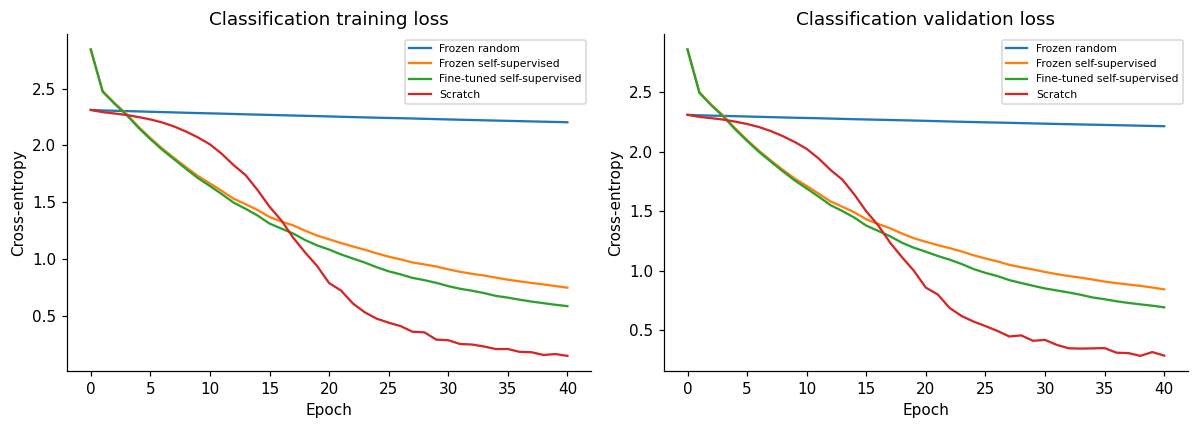

In [8]:
def classification_metrics(network, x, y):
    network.eval()
    with torch.no_grad():
        logits = network(x)
        return F.cross_entropy(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

runs = {}
for name, network in methods.items():
    frozen = name.startswith('Frozen')
    before_encoder = copy.deepcopy(network.encoder.state_dict())
    if frozen:
        optimizer = torch.optim.Adam(network.head.parameters(), lr=0.003)
    else:
        optimizer = torch.optim.Adam([
            {'params': network.encoder.parameters(), 'lr': 0.0003 if name.startswith('Fine') else 0.003},
            {'params': network.head.parameters(), 'lr': 0.003},
        ])
    shuffle = torch.Generator().manual_seed(178)
    train_loss, _ = classification_metrics(network, labeled_x, labeled_y)
    best_val, _ = classification_metrics(network, val_x, val_y)
    best_epoch, best_state = 0, copy.deepcopy(network.state_dict())
    history = [(0, train_loss, best_val)]
    updates = 0
    for epoch in range(1, 41):
        network.train()
        if frozen:network.encoder.eval()
        for ids in torch.randperm(len(labeled_x), generator=shuffle).split(64):
            optimizer.zero_grad(set_to_none=True)
            loss = F.cross_entropy(network(labeled_x[ids]), labeled_y[ids])
            assert torch.isfinite(loss)
            loss.backward()
            optimizer.step()
            updates += 1
        train_loss, _ = classification_metrics(network, labeled_x, labeled_y)
        val_loss, _ = classification_metrics(network, val_x, val_y)
        history.append((epoch, train_loss, val_loss))
        if val_loss < best_val:
            best_val, best_epoch, best_state = val_loss, epoch, copy.deepcopy(network.state_dict())
    network.load_state_dict(best_state)
    network.eval()
    assert updates == 160
    assert np.isclose(classification_metrics(network, val_x, val_y)[0], best_val, rtol=1e-6)
    if frozen:
        assert all(torch.equal(value, before_encoder[key]) for key, value in network.encoder.state_dict().items())
        assert all(p.grad is None for p in network.encoder.parameters())
    else:
        assert any(p.grad is not None and p.grad.abs().sum() > 0 for p in network.encoder.parameters())
    runs[name] = {'history': np.asarray(history), 'best_epoch': best_epoch, 'best_val_loss': best_val}
    print(name, '| selected epoch:', best_epoch, '| validation loss/accuracy:', classification_metrics(network, val_x, val_y))
selected_name = min(runs, key=lambda name: runs[name]['best_val_loss'])
print('Method selected by validation:', selected_name)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, run in runs.items():
    h = run['history']
    axes[0].plot(h[:, 0], h[:, 1], label=name)
    axes[1].plot(h[:, 0], h[:, 2], label=name)
for ax, title in zip(axes, ['Classification training loss', 'Classification validation loss']):
    ax.set(xlabel='Epoch', ylabel='Cross-entropy', title=title); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Test whether the representation helps the actual task

Evaluate every fixed method on the same 360 test images. Accuracy measures class decisions; cross-entropy measures how much probability reaches the true class. Reconstruction MSE has different units and meaning, so its numerical value cannot be compared directly to classification cross-entropy.

If frozen self-supervised features outperform frozen random features, that supports the usefulness of pretraining for this head and task. Comparing fine-tuning to scratch asks whether pretraining helps a fully adaptable network under this schedule. Either ranking could go the other way. A source objective can learn background or appearance details that do not serve the downstream labels.

The selected method was chosen with validation, not the best displayed test score. Confusion matrices are descriptive results from cached test predictions. This is one split with 200 training labels and 360 validation labels, not a guarantee of accuracy with only 200 labels in total or on unseen writers.

Frozen random: 173/360 (48.1%); cross-entropy 2.211750
Frozen self-supervised: 284/360 (78.9%); cross-entropy 0.839016
Fine-tuned self-supervised: 285/360 (79.2%); cross-entropy 0.701676
Scratch: 322/360 (89.4%); cross-entropy 0.323557


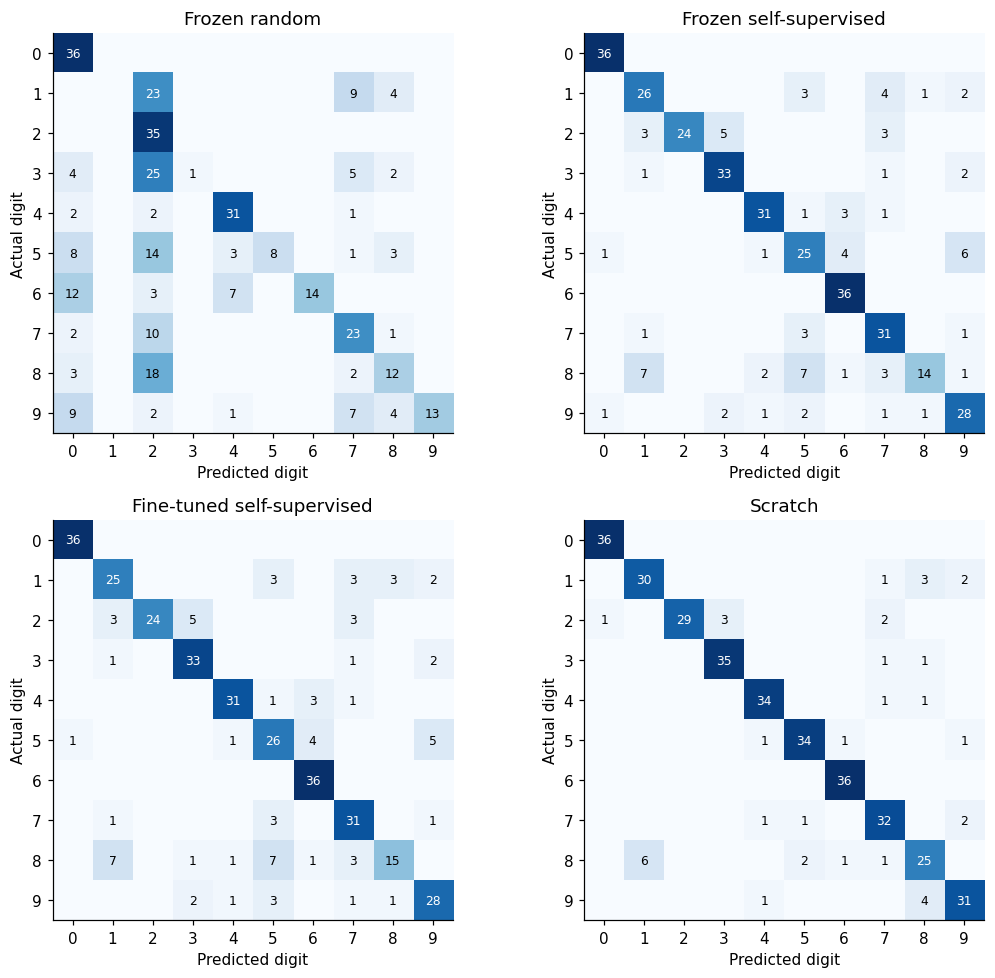

In [9]:
test_x, test_y = pixels(test_ids), torch.from_numpy(labels[test_ids])
results, probabilities_by_method, matrices = {}, {}, {}
for name, network in methods.items():
    network.eval()
    with torch.no_grad():
        logits = network(test_x)
        probability = logits.softmax(1)
        predictions = logits.argmax(1)
        loss = F.cross_entropy(logits, test_y).item()
    assert torch.isfinite(probability).all()
    torch.testing.assert_close(probability.sum(1), torch.ones(len(test_y)))
    correct = int((predictions == test_y).sum())
    results[name] = {'correct': correct, 'accuracy': correct/len(test_y), 'cross_entropy': loss}
    probabilities_by_method[name] = probability.numpy()
    matrices[name] = confusion_matrix(test_y.numpy(), predictions.numpy(), labels=np.arange(10))
    assert matrices[name].sum() == len(test_y)
    print(f'{name}: {correct}/{len(test_y)} ({correct/len(test_y):.1%}); cross-entropy {loss:.6f}')
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
vmax = max(matrix.max() for matrix in matrices.values())
for ax, (name, matrix) in zip(axes.flat, matrices.items()):
    ax.imshow(matrix, cmap='Blues', vmin=0, vmax=vmax)
    for r in range(10):
        for c in range(10):
            if matrix[r, c]:ax.text(c, r, str(matrix[r, c]), ha='center', va='center', fontsize=8,
                                   color='white' if matrix[r, c] > vmax/2 else 'black')
    ax.set(title=name, xlabel='Predicted digit', ylabel='Actual digit', xticks=range(10), yticks=range(10))
plt.tight_layout(); plt.show()

## Preserve the representation and its input contract

The target classifier expects clean 8 × 8 grayscale values scaled by 16 and appends a zero mask channel internally. Keep that convention with the weights and class mapping. Passing only one channel directly to the pretrained encoder would violate the architecture, while using a nonzero mask would describe a different input condition.

We save the validation-selected classifier into a temporary checkpoint with its architecture, pixel divisor, image shape, class names, and mask convention. Restoring the metadata and weights reproduces the same probabilities. The reconstruction decoder is no longer required for digit classification.

This saved model recognizes cropped digits from the demonstrated input format. It does not locate digits in photographs, resize arbitrary images, or identify inputs outside the known ten classes. Those would require separately designed and evaluated behavior.

In [10]:
chosen_model = methods[selected_name]
bundle = {'state_dict': copy.deepcopy(chosen_model.state_dict()),
          'architecture': 'two_channel_encoder64_head10_v1', 'pixel_divisor': 16.0,
          'image_shape': [8, 8], 'mask_convention': 'second_channel_zero_for_clean_classification',
          'class_names': [str(i) for i in range(10)], 'selected_method': selected_name}
with tempfile.TemporaryDirectory() as directory:
    checkpoint = Path(directory) / 'self_supervised_digits.pt'
    torch.save(bundle, checkpoint)
    restored = torch.load(checkpoint, map_location='cpu', weights_only=True)
    assert restored['architecture'] == bundle['architecture']
    assert restored['mask_convention'] == bundle['mask_convention']
    restored_model = DigitClassifier(random_encoder_state, initial_head)
    restored_model.load_state_dict(restored['state_dict'])
    restored_model.eval()
    example_raw = raw_images[test_ids[:3]]
    assert list(example_raw.shape[1:]) == restored['image_shape']
    prepared = torch.from_numpy(example_raw / restored['pixel_divisor'])[:, None]
    with torch.no_grad():
        restored_probability = restored_model(prepared).softmax(1).numpy()
    np.testing.assert_allclose(restored_probability, probabilities_by_method[selected_name][:3], atol=1e-6)
    assert restored['class_names'] == [str(i) for i in range(10)]
print('Validation-selected method:', selected_name)
print('Checkpoint restored matching probabilities and input conventions; temporary file removed.')

Validation-selected method: Scratch
Checkpoint restored matching probabilities and input conventions; temporary file removed.


## Read the saved reference run

Masked-reconstruction validation selected pretraining epoch 30. Its masked-pixel MSE was 0.042529, compared with 0.073590 for the training mean-image baseline. Pretraining used 861 training images and 216 separate validation images without class-label losses.

All downstream methods used 200 labeled training images, 360 validation images, and 360 test images. Classification validation selected **Scratch** as the model to save before test evaluation.

| Method | Selected classification epoch | Correct | Accuracy | Cross-entropy |
| --- | --- | --- | --- | --- |
| Frozen random | 40 | 173/360 | 48.1% | 2.211750 |
| Frozen self-supervised | 40 | 284/360 | 78.9% | 0.839016 |
| Fine-tuned self-supervised | 40 | 285/360 | 79.2% | 0.701676 |
| Scratch | 38 | 322/360 | 89.4% | 0.323557 |

Reconstruction success and classification success answer different questions. These single-split results describe the chosen masks, encoder, learning rates, and label budget; no settings were retuned using the test scores. The original random encoder and identical head initialization provide explicit controls, but pretraining adds data and compute. Frozen-encoder and save/restore checks passed.

In this run, frozen self-supervised features supported much better classification than the frozen random control (78.9% versus 48.1%), while fine-tuning reached 79.2% and scratch reached 89.4%. Thus the reconstruction task learned useful features for the chosen head-training schedule, but neither reuse method beat scratch. The experiment does not isolate whether a different pretraining objective, encoder, feature scaling, or adaptation schedule would change that ranking.

## What the ANN learned, and why we still need evaluation

The self-supervised objective taught the encoder to retain information useful for predicting missing image values. The decoder translated features back into pixels during that phase. A new head then translated the same feature format into digit scores. Fine-tuning additionally let class errors reshape the encoder.

Self-supervision is not learning without a loss, without targets, or without design choices. The targets are generated from the data; masks, architecture, and objective define what the network is encouraged to preserve. Contrastive learning defines that encouragement differently, through relationships between views.

A useful pretraining task can reduce dependence on class labels, but it can also learn the wrong details for the intended task. Compare with random features and scratch training, protect held-out data, count validation labels and pretraining compute, and preserve the complete inference recipe. The observed results support conclusions about this specific experiment rather than a universal advantage for self-supervision.